In [10]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import numpy as np
import maptools
import os

import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from multiprocessing import Pool
import pickle
import h5py
from datetime import datetime

maptools.job.info()
maptools.plot.dark()
!which python

import time
import numba
import ImageD11.columnfile
import ImageD11.sinograms.dataset
import ImageD11.sinograms.geometry as geometry
import ImageD11.sinograms.point_by_point
import ImageD11.sinograms.point_by_point as pbp
from ImageD11.nbGui import nb_utils as utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
root = "/data/visitors/danmax/20251117/2025110808/process/al1050_15pct_center_slice"
filetag = "medium_pks_18M_2025_1213_095603"
pbp_map_path = os.path.join(root, filetag + "_pbpmap.h5")
dset_path = os.path.join(root, filetag + "_dummy_dset.h5")
colf_path = os.path.join(root, filetag + "_colf.h5")
# y0 = maptools.constants.ROTATION_AXIS_DTY_SHIFT
# assert os.path.isfile(pbp_map_path)
# assert os.path.isfile(dset_path)
# assert os.path.isfile(colf_path)

In [34]:
pbpmap.j.min()

-79.0

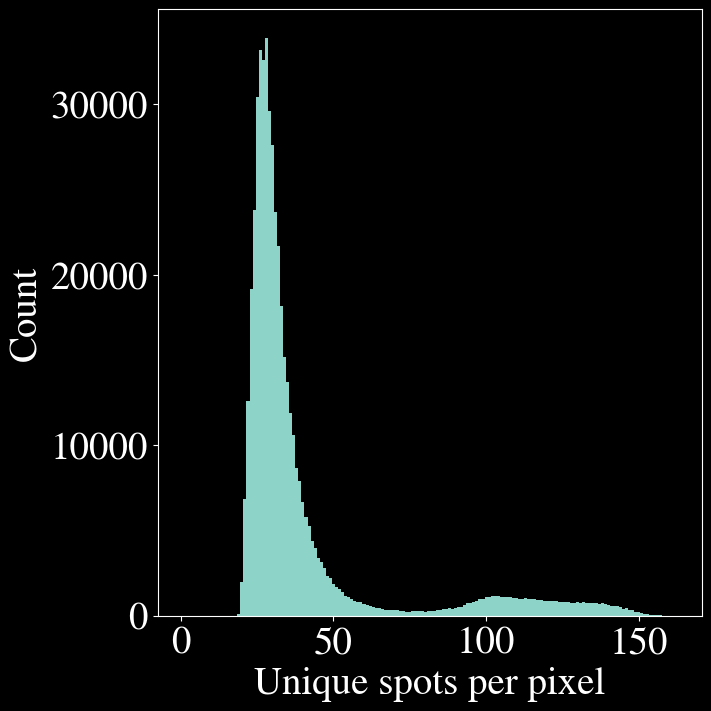

In [33]:
colf = ImageD11.columnfile.colfile_from_hdf(colf_path)
pbpmap = pbp.PBPMap(pbp_map_path)
dset = maptools.dummy.load_dset(dset_path)
pbpmap.plot_nuniq_hist()

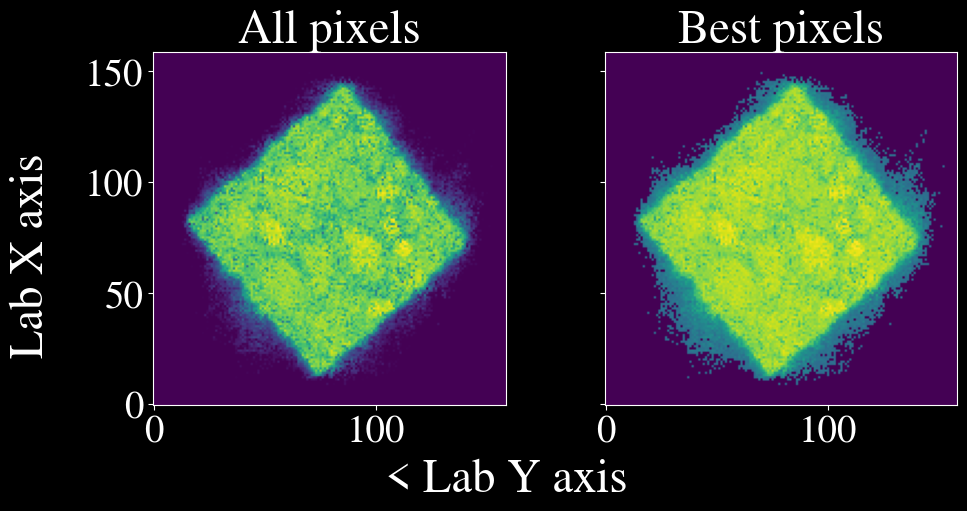

In [34]:
pbpmap.choose_best(minpeaks=55)
pbpmap.plot_best(minpeaks=55)

In [35]:
dset.refmapfile = pbp_map_path  # pbp map input
dset.refpeaksfile = os.path.join(
    root, "icolfile_refine_" + filetag + ".h5"
)  # icolf for refinement
dset.refoutfile = os.path.join(
    root, "pbpmap_refine_" + filetag + ".h5"
)  # refined pbp map output
dset.refmanfile = os.path.join(root, "pbprefiner_" + filetag + ".h5")  # myself as an H5

hkl_tol = 0.05  # only peaks that bit within this tolerance in reciprocal space to an integer h,k,l point are considered assigned to grain
ds_tol = 0.01  # Deviation from predicted theoretical ring value beyond which the peak is discared. In units of inverse angstrom i.e (1 / d)-tolerance where d is the lattice d-spacing
eta_wedge_in_degrees = 6  # Peaks close to eta=0 and eta=180 stay in diffraction all the time in omega, these are not good peaks to use.

etacut = np.sin(np.radians(np.abs(eta_wedge_in_degrees)))

refiner = pbp.PBPRefine(
    dset,
    phase_name=None,
    hkl_tol_origins=hkl_tol + 0.02,
    hkl_tol_refine=hkl_tol,
    hkl_tol_refine_merged=hkl_tol,
    ds_tol=ds_tol,
    etacut=etacut,
    ifrac=None,
    forref=None,
    y0=y0,
    min_grain_npks=30,
)

In [36]:
refiner.setmap(pbpmap)

In [37]:
refiner.setpeaks(colf, del_existing=False, prompt_del=True)

0 0.4272 (1, 1, 1) 8 390173 used, sum_intensity> 2079.066225165563
1 0.4933 (0, 2, 0) 6 269357 used, sum_intensity> 1511.1721854304635
2 0.6977 (0, 2, 2) 12 692686 used, sum_intensity> 670.8874172185431
3 0.8181 (1, 1, 3) 24 1571099 used, sum_intensity> 426.1655629139073
4 0.8545 (2, 2, 2) 8 502727 used, sum_intensity> 375.8675496688742
5 0.9867 (0, 4, 0) 6 534544 used, sum_intensity> 173.79470198675497
6 1.0752 (3, 3, 1) 24 873310 used, sum_intensity> 296.7549668874172
7 1.1031 (2, 4, 0) 24 1907084 used, sum_intensity> 120.90066225165563
8 1.2084 (4, 2, 2) 24 1126940 used, sum_intensity> 128.2980132450331
9 1.2817 (1, 5, 1) 32 259704 used, sum_intensity> 341.74834437086093
10 1.3954 (4, 4, 0) 12 87803 used, sum_intensity> 176.5430463576159
11 1.4593 (5, 1, 3) 48 383984 used, sum_intensity> 118.24503311258277
12 1.4800 (2, 4, 4) 30 23108 used, sum_intensity> 285.57615894039736
13 1.5601 (2, 0, 6) 24 40835 used, sum_intensity> 105.23178807947019
14 1.6175 (3, 3, 5) 24 19115 used, sum_in

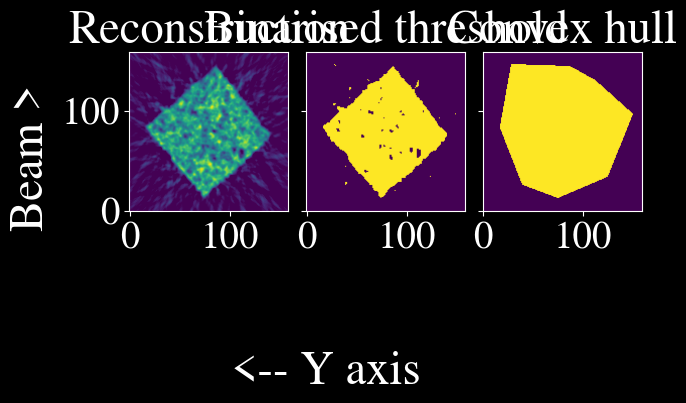

In [41]:
refiner.setmask(manual_threshold=0.15, doplot=True, use_icolf=True)

In [42]:
refiner.setsingle(pbpmap, method="best", minpeaks=50)

In [43]:
refiner.get_origins(guess_speed=True, guess_npks=10000, save_peaks_after=True)

Getting gvecs...
Running test function twice for the first 10000 peaks to guess speed...
This is because we get speed advantages with peaks on consecutive frames
First time to trigger NJIT
Now we time
I estimate roughly 7.710853648745104 seconds for all peaks in self.icolf
That's 0.002141903791318084 hours
Lexsort...
Running numba computation on 47 threads, may take a while!
xpos_refined column added to self.icolf
Saving self.icolf to disk with new column


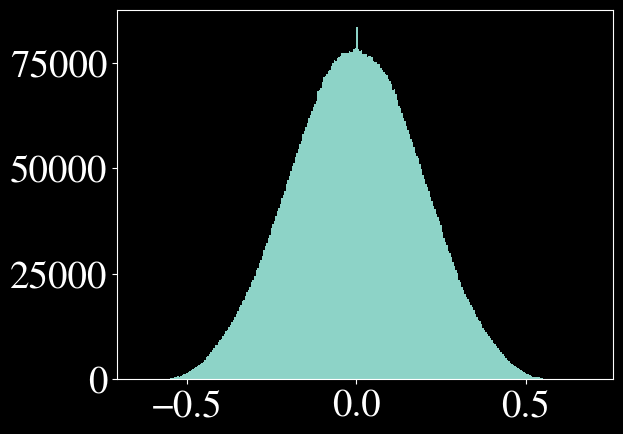

In [44]:
plt.figure()
plt.hist(refiner.icolf.xpos_refined, bins=300)
plt.show()

In [45]:
refiner.run_refine(
    points_step_space=None,
    npoints=None,
    output_filename="tmp_" + filetag,
    use_cluster=False,
    pythonpath=None,
)

Launching Numba parallel refinement on 47 threads
Saving refined map to disk


In [46]:
refiner.refinedmap_filename

'tmp_medium_pks_18M_2025_1213_095603'

Reading your columnfile in hdf format


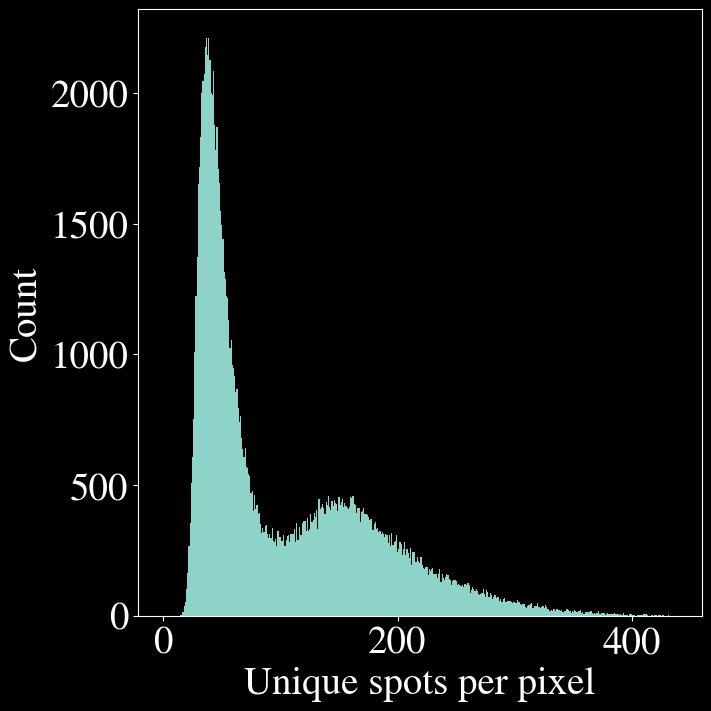

In [47]:
refined_pbpmap = pbp.PBPMap(refiner.refinedmap_filename)
refined_pbpmap.plot_nuniq_hist()

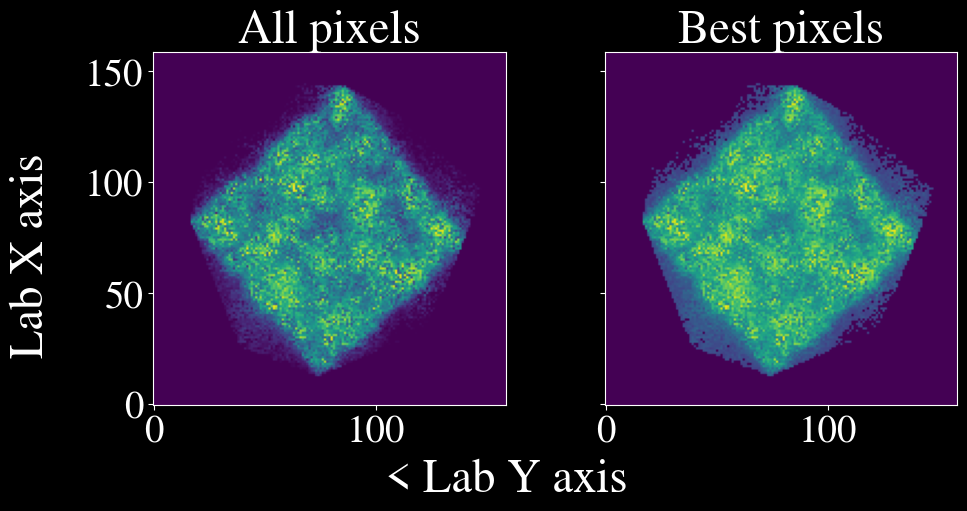

In [48]:
refined_pbpmap.choose_best(minpeaks=80)
refined_pbpmap.plot_best(minpeaks=80)

In [49]:
ucell = maptools.constants.UNITCELL

grains = []
for ubi in refined_pbpmap.best_ubi.reshape(-1, 3, 3):
    if not np.isnan(ubi).any():
        g = ImageD11.grain.grain(ubi)
        g.ref_unitcell = ucell
        grains.append(g)

m = ~np.isnan(refined_pbpmap.best_ubi[:, :, 0, 0])
from ImageD11.nbGui import nb_utils as utils

utils.get_rgbs_for_grains(grains)
gmap = np.empty(m.shape, dtype=object)
gmap[m] = grains

In [50]:
ubimap = refined_pbpmap.best_ubi
rgbmap = np.zeros((*m.shape, 3))
for i in range(ubimap.shape[0]):
    for j in range(ubimap.shape[1]):
        if ~np.isnan(ubimap[i, j]).any():
            rgbmap[i, j] = gmap[i, j].rgb_z

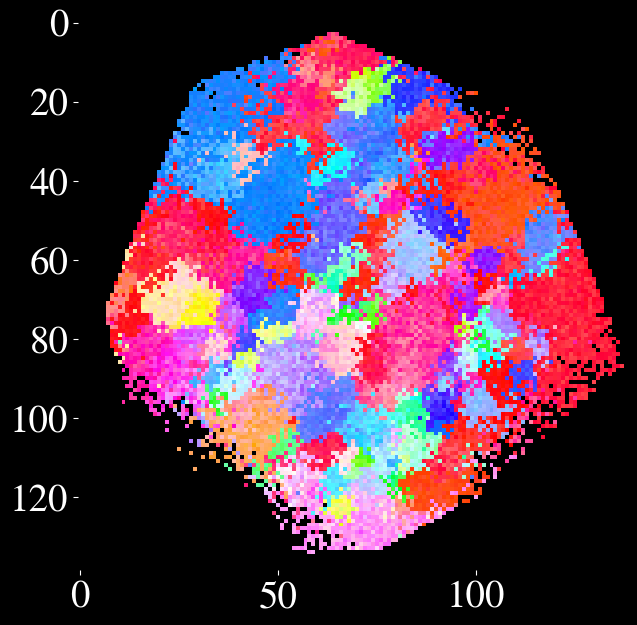

In [51]:
plt.style.use("dark_background")
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
from scipy.ndimage import gaussian_filter

s = refined_pbpmap.best_nuniq[:, :, None].astype(float)
s = gaussian_filter(s, 1)
s /= s.max()
s[s < 0.1] = 0
s[s > 0] = 1
for spine in ax.spines.values():
    spine.set_visible(False)
im = ax.imshow((rgbmap * s)[10:-10, 10:-10])
plt.tight_layout()
plt.show()

In [52]:
refined_pbpmap.writefile(dset.refoutfile)
dset.save()

In [53]:
dset.refoutfile.split("/")[-1][14:-3]

'medium_pks_18M_2025_1213_095603'